### Data loading

In [38]:
import pandas as pd
cluster = pd.read_csv('../cluster_hippo_260904.csv', index_col=0)
trimap = pd.read_csv('../trimap_hippo_260904.csv', index_col=0)

In [39]:
chronos = pd.read_csv("../data/CRISPR_gene_effect.csv",index_col=0)
chronos.columns = [c.split()[0].upper() + '_Chronos' for c in chronos.columns]
expression = pd.read_csv("../data/CCLE_expression.csv", index_col=0)
expression.columns = [c.split()[0].upper()+'_Expression' for c in expression.columns]
sample_info = pd.read_csv("../data/sample_info.csv", index_col=0)
ch_ex = chronos.merge(expression, right_index=True, left_index=True).dropna()
ch_ex['Cluster'] = cluster['Cluster']

### Heatmap (Figs. 2c, 2g, 3a, S10a, S10b)

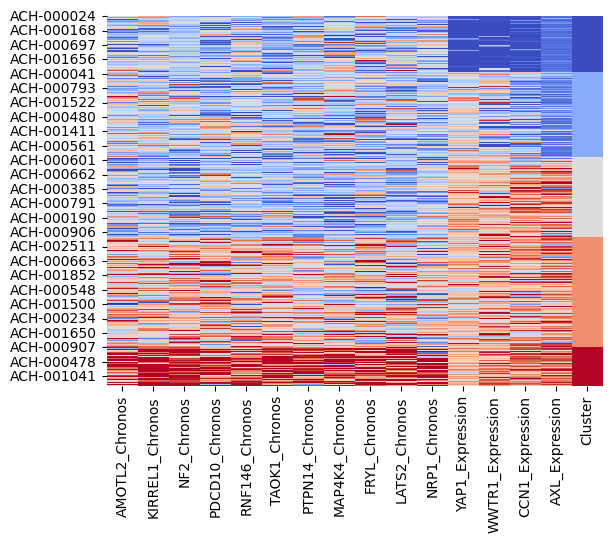

In [40]:
#Fig. 2c
import seaborn as sns
import matplotlib.pyplot as plt
hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']
features = [gene + '_Chronos' for gene in hippo_chr] + [gene + '_Expression' for gene in hippo_exp] 
ch_ex2 = ch_ex[features + ['Cluster']].copy().sort_values('Cluster')
ch_ex2 = (ch_ex2-ch_ex2.mean())/ch_ex2.std()
#ch_ex2 = ch_ex2.join(trimap, how='inner').sort_values('Cluster')
ch_ex2 = ch_ex2.dropna()    
sns.heatmap(ch_ex2, cmap="coolwarm",vmax=1.5, vmin=-1.5,cbar=False)
plt.savefig("../result/figure.svg")

plt.show()

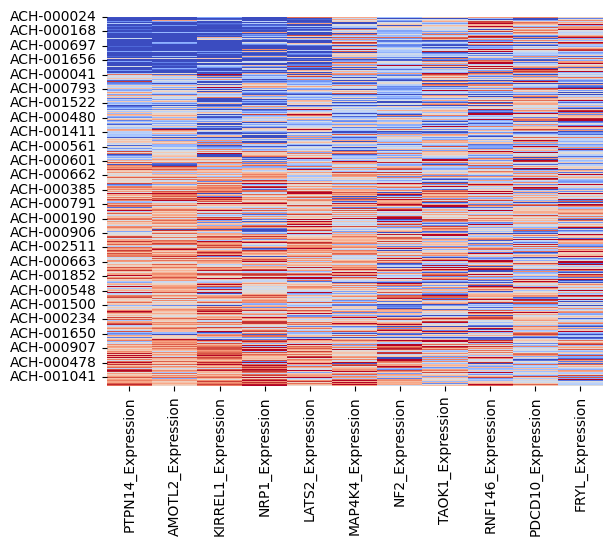

In [ ]:
#Fig. S10a, S10b

#Fig. S10a
hippo_chr=[]
hippo_exp=['CCN1','CCN2','AMOTL2','ANKRD1', 'IGFBP3', 'F3', 'FJX1', 'NUAK2', 
           'LATS2', 'CRIM1', 'GADD45A', 'TGFB2', 'PTPN14', 'NT5E', 'FOXF2', 
           'AXL', 'DOCK5', 'ASAP1', 'RBMS3', 'MYOF', 'ARHGEF17', 'CCDC80',]
#Fig. S10b
hippo_exp = ['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']


features = [gene + '_Chronos' for gene in hippo_chr] + [gene + '_Expression' for gene in hippo_exp] 
ch_ex2 = ch_ex[features + ['Cluster']].copy().sort_values('Cluster')
ch_ex2 = (ch_ex2-ch_ex2.mean())/ch_ex2.std()
corrs = []
for x in ch_ex2.columns:
    corr = ch_ex2[x].corr(ch_ex2['Cluster'])
    corrs.append((x, corr))
corrs = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)
ch_ex3 = ch_ex2[[x[0] for x in corrs]]
sns.heatmap(ch_ex3.drop('Cluster', axis=1), cmap="coolwarm",vmax=1.5, vmin=-1.5,cbar=False)
plt.savefig('../result/figure.svg')
plt.show()

100%|██████████| 5/5 [00:03<00:00,  1.27it/s]


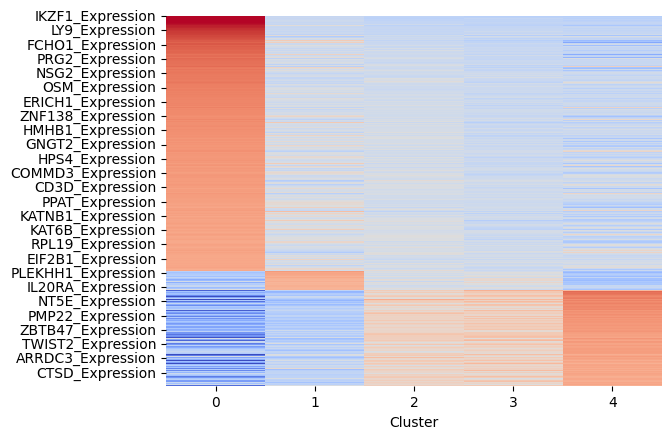

In [43]:
#Fig. 2g
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

norm_ch_ex = pd.DataFrame(StandardScaler().fit_transform(ch_ex), columns=ch_ex.columns, index=ch_ex.index)
norm_ch_ex['Cluster'] = ch_ex['Cluster']
ch_exg = norm_ch_ex.groupby("Cluster").mean().copy().T

from tqdm import tqdm
results = []

for i in tqdm(range(5)):
    df_filtered = ch_exg[ch_exg[i] == ch_exg.max(axis=1)].copy()
    #df_filtered = ch_exg[ch_exg[i] == ch_exg.min(axis=1)].copy()

    df_filtered['diff_to_other_mean'] = df_filtered.apply(lambda row: row[i] - row.drop(i).mean(), axis=1)
    df_sorted = df_filtered.sort_values(by='diff_to_other_mean', ascending=False)
    #df_sorted = df_filtered.sort_values(by='diff_to_other_mean', ascending=True)

    df_sorted = df_sorted[df_sorted['diff_to_other_mean'] > 0.75]

    results.append(df_sorted.index.tolist())

rows = []
for i in range(5):
    ex_results = [r for r in results[i] if 'Expression' in r]
    rows += ex_results#[:50]
a = ch_exg.loc[rows]

results_ex = results
high_exp = ex_results  #Cluster4=Hippo_strong

sns.heatmap(a, cmap="coolwarm",vmax=1.5, vmin=-1.5,cbar=False)
plt.savefig("../result/figure.svg")
plt.show()

In [44]:
for r in results:
    print(len(r))

1777
128
1
1
755


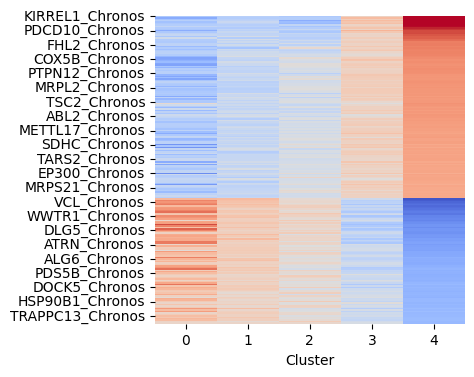

In [46]:
#Fig. 3a
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

norm_ch_ex = pd.DataFrame(StandardScaler().fit_transform(ch_ex), columns=ch_ex.columns, index=ch_ex.index)
norm_ch_ex['Cluster'] = ch_ex['Cluster']
ch_exg = norm_ch_ex.groupby("Cluster").mean().copy().T

from tqdm import tqdm
results = []
i = 4

df_filtered = ch_exg[ch_exg[i] == ch_exg.max(axis=1)].copy()
df_filtered['diff_to_other_mean'] = df_filtered.apply(lambda row: row[i] - row.drop(i).mean(), axis=1)
df_sorted = df_filtered.sort_values(by='diff_to_other_mean', ascending=False)
df_sorted = df_sorted[df_sorted['diff_to_other_mean'] > 0.75]
results.append(df_sorted.index.tolist())

df_filtered = ch_exg[ch_exg[i] == ch_exg.min(axis=1)].copy()
df_filtered['diff_to_other_mean'] = df_filtered.apply(lambda row: row[i] - row.drop(i).mean(), axis=1)
df_sorted = df_filtered.sort_values(by='diff_to_other_mean', ascending=True)
df_sorted = df_sorted[df_sorted['diff_to_other_mean'] < -0.75]

results.append(df_sorted.index.tolist())

rows = []
for i in range(2):
    ch_results = [r for r in results[i] if 'Chronos' in r]
    
    rows += ch_results#[:50]
a = ch_exg.loc[rows]

low_chr = ch_results#[:50]  

plt.figure(figsize=(4, 4))
sns.heatmap(a, cmap="coolwarm",vmax=1.5, vmin=-1.5,cbar=False)
plt.savefig("../result/figure.svg")
plt.show()

### Violin plots (Figs. 2h, 3b, d, S11c, d)

C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\1399332151.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("rainbow", 5)
C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\1399332151.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ch_ex, x="Cluster", y=value, palette = custom_palette, cut=0)


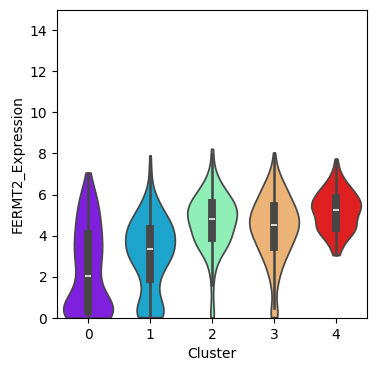

Cliffs delta: -0.4651466836734694, Magnitude: medium


In [47]:
#Fig. 2h
from cliffs_delta import cliffs_delta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
cmap = cm.get_cmap("rainbow", 5) 
custom_palette = [cmap(i) for i in range(5)]
custom_palette = [(cmap(i)[0], cmap(i)[1], cmap(i)[2], 0.5) for i in range(5)]
value = "FERMT2_Expression"

plt.figure(figsize=(4, 4))
sns.violinplot(data=ch_ex, x="Cluster", y=value, palette = custom_palette, cut=0) 
plt.ylim(0, 15)
plt.savefig("../result/figure.svg")

plt.show()
a = ch_ex.loc[ch_ex["Cluster"] != 4, value].dropna()
b = ch_ex.loc[ch_ex["Cluster"] == 4, value].dropna()
d, magnitude = cliffs_delta(a, b)
print(f"Cliffs delta: {d}, Magnitude: {magnitude}")

C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\989792480.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("rainbow", 5)
C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\989792480.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ch_ex, x="Cluster", y=value, palette = custom_palette, cut=0)


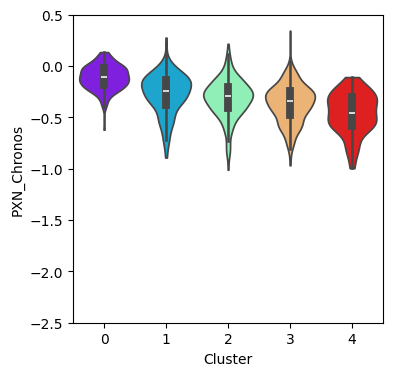

Cliffs delta: 0.4646896258503401, Magnitude: medium


In [ ]:
#Fig. 3b, 3d, S11d
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
cmap = cm.get_cmap("rainbow", 5) 
custom_palette = [cmap(i) for i in range(5)]
custom_palette = [(cmap(i)[0], cmap(i)[1], cmap(i)[2], 0.5) for i in range(5)]
value = "PXN_Chronos"

plt.figure(figsize=(4, 4))
sns.violinplot(data=ch_ex, x="Cluster", y=value, palette = custom_palette, cut=0) 
plt.ylim(-2.5, 0.5)
plt.savefig("../result/figure.svg")
plt.show()

a = ch_ex.loc[ch_ex["Cluster"] != 4, value].dropna()
b = ch_ex.loc[ch_ex["Cluster"] == 4, value].dropna()
d, magnitude = cliffs_delta(a, b)
print(f"Cliffs delta: {d}, Magnitude: {magnitude}")

Cliffs delta: -0.8313430868591011, Magnitude: large


C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\498275166.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("rainbow", 5)
C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\498275166.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=coa, x="Cluster", y=value, palette = custom_palette, cut=0)


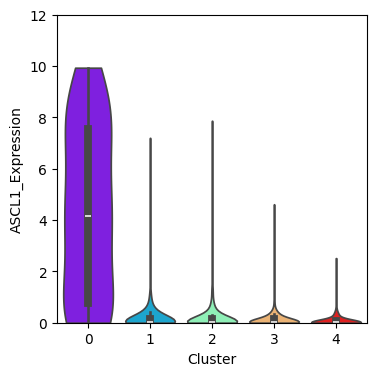

In [ ]:
#Fig. S11c
model = pd.read_csv("../data/Model.csv", index_col=0)
cm = ch_ex.join(model, how='inner')#.dropna()
coa = cm[~cm.OncotreeLineage.isin(['Lymphoid', 'Myeloid'])]#.groupby('Cluster').mean()
#coa = cm[cm.OncotreeLineage.isin(['Breast'])]#.groupby('Cluster').mean()

value = "ASCL1_Expression"
a = coa.loc[coa["Cluster"] != 0, value].dropna()
b = coa.loc[coa["Cluster"] == 0, value].dropna()
d, magnitude = cliffs_delta(a, b)
print(f"Cliffs delta: {d}, Magnitude: {magnitude}")

#cm[['Cluster', 'SYP_Expression']].groupby('Cluster').mean()
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
cmap = cm.get_cmap("rainbow", 5) 
custom_palette = [cmap(i) for i in range(5)]
custom_palette = [(cmap(i)[0], cmap(i)[1], cmap(i)[2], 0.5) for i in range(5)]

plt.figure(figsize=(4, 4))
sns.violinplot(data=coa, x="Cluster", y=value, palette = custom_palette, cut=0) 
plt.ylim(0, 12)
plt.savefig("../result/figure.svg")
plt.show()


### Cancer type distribution (Fig. S2f, S11a, b, S12)

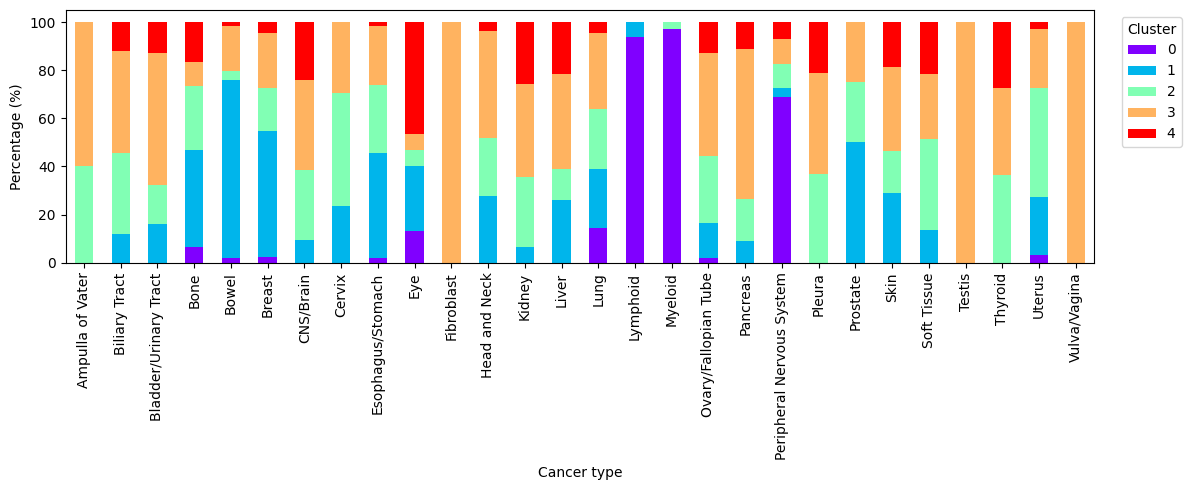

In [ ]:
#Fig. S2f, S11a
model = pd.read_csv("../data/Model.csv", index_col=0)
cm = ch_ex.join(model, how='inner')#.dropna()
import matplotlib.pyplot as plt

dist = pd.crosstab(cm['OncotreeLineage'], cm['Cluster'], normalize='index') * 100

dist.plot(kind='bar', stacked=True, figsize=(12, 5), cmap='rainbow')
plt.ylabel('Percentage (%)')
plt.xlabel('Cancer type')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('../result/figure.svg')
plt.show()

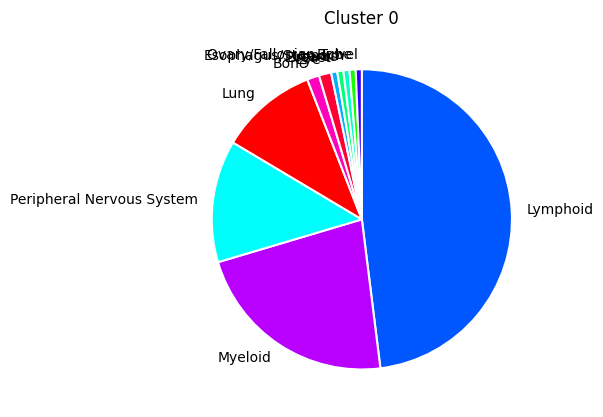

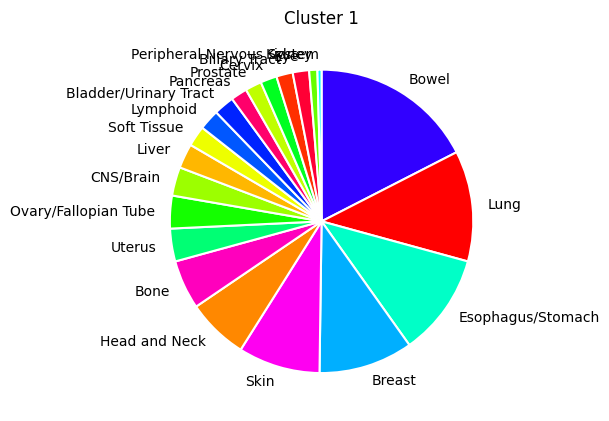

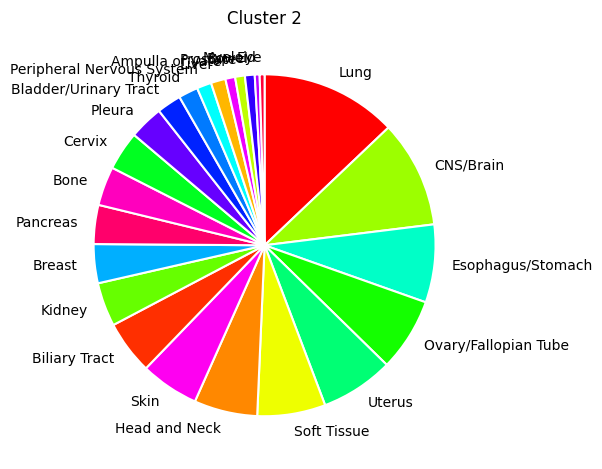

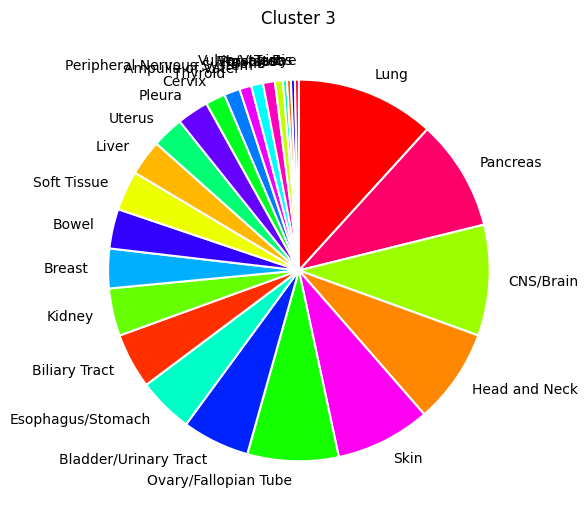

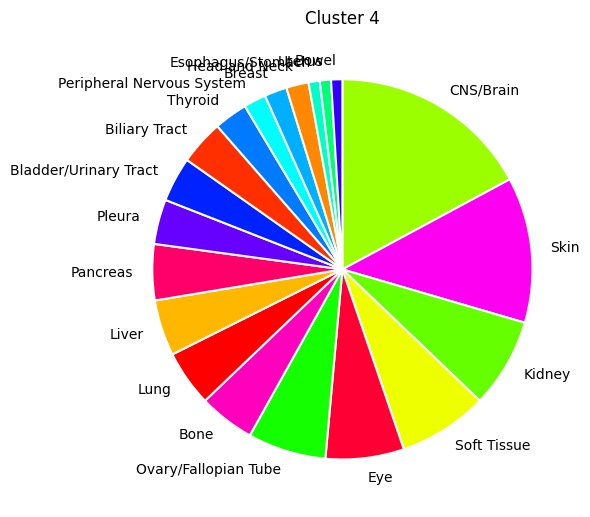

In [51]:
#Fig. S11b
import numpy as np
import matplotlib.pyplot as plt

# Rank tissues by total abundance
tissues = cm['OncotreeLineage'].value_counts().index
n = len(tissues)

# Spread colors around the rainbow more distinctly
x = (np.arange(n) * 0.61803398875) % 1
colors = plt.cm.hsv(x)
color_map = dict(zip(tissues, colors))

for cluster, df in cm.groupby('Cluster'):
    counts = df['OncotreeLineage'].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(6, 6))
    plt.pie(
        counts,
        labels=counts.index,
        colors=[color_map[x] for x in counts.index],
        #alpha=0.4,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    plt.title(f'Cluster {cluster}')
    plt.tight_layout()
    plt.savefig(f'../result/figure_cluster_{cluster}.svg')
    plt.show()

C:\Users\ki949\AppData\Local\Temp\ipykernel_29552\2483546473.py:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


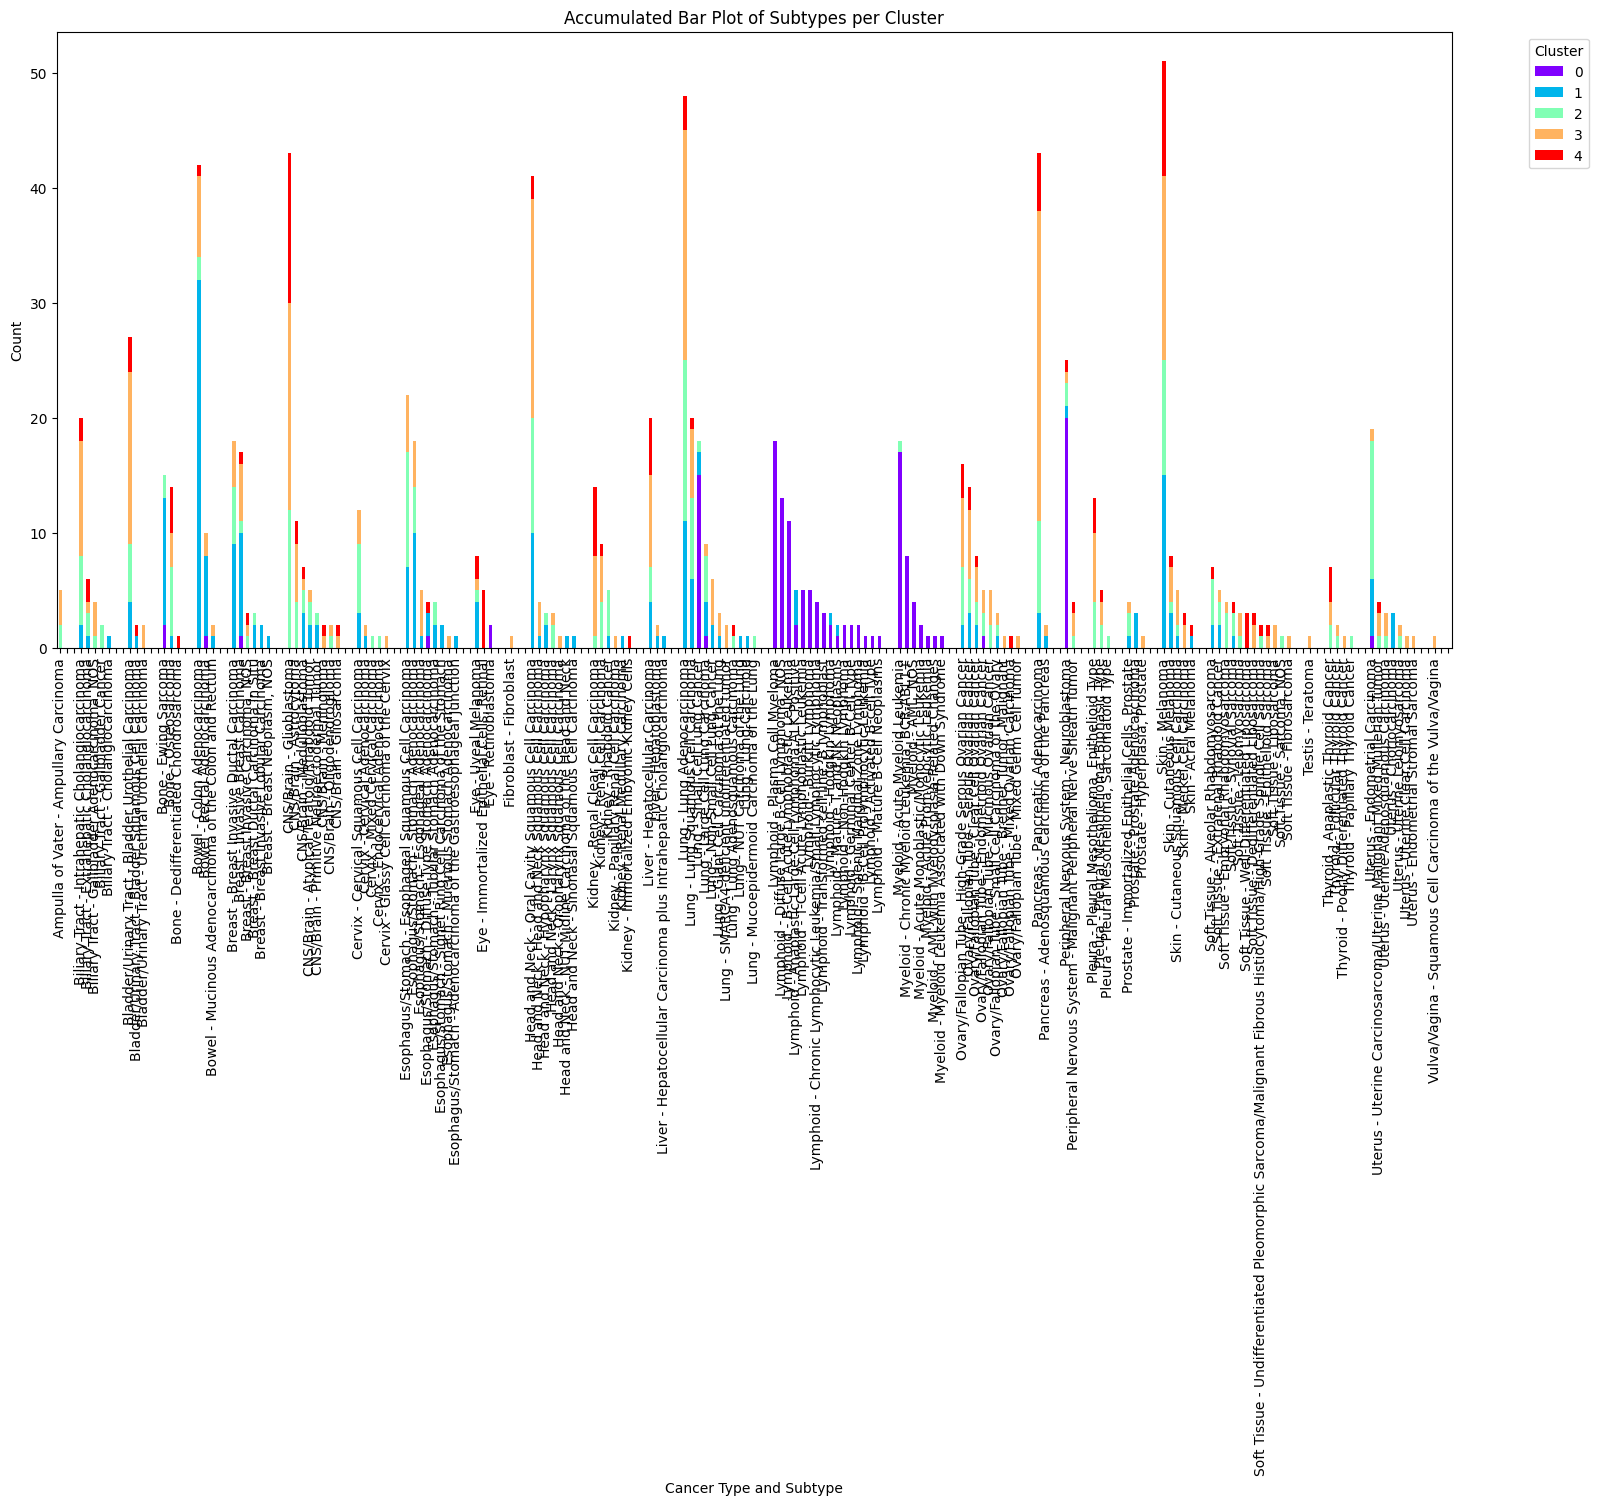

In [ ]:
#Fig. S12
import pandas as pd
import matplotlib.pyplot as plt

coa2 = cm.copy()
subtype_counts = coa2['OncotreeSubtype'].value_counts()
coa2['Subtype_Count'] = coa2['OncotreeSubtype'].map(subtype_counts)
coa2 = coa2.sort_values(['OncotreeLineage', 'Subtype_Count'], ascending=[True, False])
coa2['Lineage_Subtype'] = coa2['OncotreeLineage'] + ' - ' + coa2['OncotreeSubtype']

crosstab_df = pd.crosstab(coa2['Lineage_Subtype'], coa2['Cluster'])
ordered_labels = []
for lineage, group in coa2.groupby('OncotreeLineage', sort=True):
    subtypes = group[['OncotreeSubtype', 'Subtype_Count']].drop_duplicates()
    subtypes = subtypes.sort_values('Subtype_Count', ascending=False)
    for subtype in subtypes['OncotreeSubtype']:
        label = f'{lineage} - {subtype}'
        if label in crosstab_df.index:
            ordered_labels.append(label)
    ordered_labels.append(' ')  # spacer
    ordered_labels.append(' ')  # spacer


ordered_labels = [l for l in ordered_labels if l in crosstab_df.index or l == ' ']

# Build the final DataFrame with spacer rows
crosstab_with_spacers = pd.DataFrame(index=ordered_labels, columns=crosstab_df.columns)
for label in ordered_labels:
    if label != ' ':
        crosstab_with_spacers.loc[label] = crosstab_df.loc[label]
    else:
        crosstab_with_spacers.loc[label] = 0

# --- Step 4: plot ---
ax = crosstab_with_spacers.plot(
    kind='bar', stacked=True, figsize=(18, 8), cmap='rainbow',# color=custom_palette
)

plt.title('Accumulated Bar Plot of Subtypes per Cluster')
plt.xlabel('Cancer Type and Subtype')
plt.ylabel('Count')

# Rotate x-axis labels 90° (vertical)
plt.xticks(rotation=90)

plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('../result/stacked_bar_plot_all_cancers_sorted_spacers1.svg', bbox_inches='tight')
plt.show()


### RNA seq (Fig. 5d, f, S15b)

In [52]:
import pandas as pd
rnaseq = pd.read_csv("../data/RNAseq.csv")
deg = pd.read_csv("../data/RNAseq_edger_results.csv")
import numpy as np
deg["-log10(FDR)"] = -np.log10(deg["FDR"])
df_up = deg[(deg["logFC"]>2) & (deg["-log10(FDR)"]>2)]
df_down = deg[(deg["logFC"]<-2) & (deg["-log10(FDR)"]>2)]

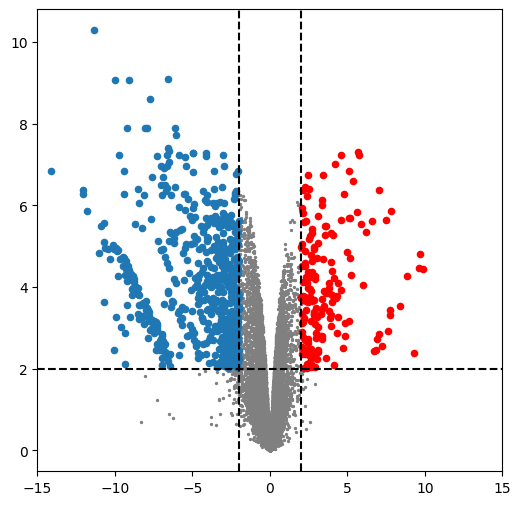

In [53]:
#Fig. 5d
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.xlim((-15,15))
plt.scatter(deg["logFC"],deg["-log10(FDR)"],s=2,c="gray")
plt.scatter(df_up["logFC"],df_up["-log10(FDR)"],s=20,c="red")
plt.scatter(df_down["logFC"],df_down["-log10(FDR)"],s=20)
plt.axvline(2,color="black",linestyle="dashed")
plt.axhline(2,color="black",linestyle="dashed")
plt.axvline(-2,color="black",linestyle="dashed")
plt.show()

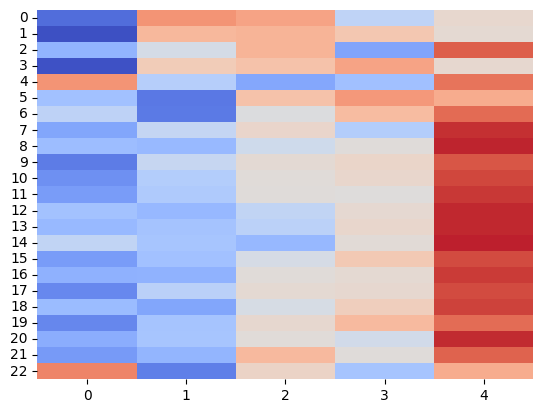

In [ ]:
#Fig. 5f, S15b
#Downregulated, cell-cell adhesion via plasma-membrane adhesion molecules
genes_down ="""AMIGO1
CADM4
CDH10
CLDN1
CLSTN2
ICAM1
MMP24
PCDHA6
PCDHB10
PCDHB13
PCDHB14
PCDHB16
PCDHB9
PCDHGA1
PCDHGA11
PCDHGA2
PCDHGA9
PCDHGB1
PCDHGB2
PCDHGB5
PCDHGB7
SCARF2
TRO""".strip().split()

#Upregulated, antigen processing and presentation of exogenous peptide antigen via MHC class II
genes_up="""CD74
CTSS
HLA-DMB
HLA-DPA1
HLA-DPB1
HLA-DRA
HLA-DRB1
HLA-DRB5""".strip().split()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
a = ch_ex.groupby("Cluster").mean()[[g+"_Expression" for g in genes_down]]
a = pd.DataFrame(StandardScaler().fit_transform(a)).T

sns.heatmap(a, cmap="coolwarm", vmin=-2,vmax=2,cbar=False)
plt.show()


### PRISM (Fig. 6d)


In [55]:
import pandas as pd
prism = pd.read_csv('../data/PRISM.csv', index_col=0)
cluster = pd.read_csv('../cluster_hippo_260904.csv', index_col=0)
cluster_p = cluster.merge(prism, left_index=True, right_index=True, how='inner')

C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\1651786305.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("rainbow", 5)
C:\Users\ki949\AppData\Local\Temp\ipykernel_11848\1651786305.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cluster_p, x="Cluster", y=value, palette = custom_palette, cut=0)


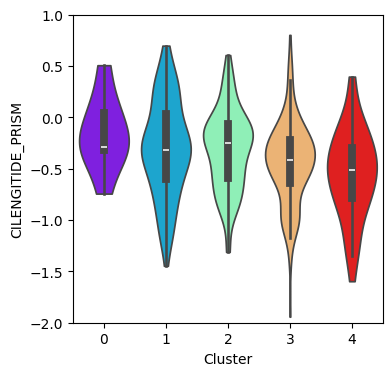

Cliffs delta: 0.24762561680904122, Magnitude: small
Median of a: -0.321862554739, Median of b: -0.509873030879


In [56]:
#Fig. 6d
from cliffs_delta import cliffs_delta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
cmap = cm.get_cmap("rainbow", 5) 
custom_palette = [cmap(i) for i in range(5)]
custom_palette = [(cmap(i)[0], cmap(i)[1], cmap(i)[2], 0.5) for i in range(5)]
value = "CILENGITIDE_PRISM"

plt.figure(figsize=(4, 4))
sns.violinplot(data=cluster_p, x="Cluster", y=value, palette = custom_palette, cut=0) 
plt.ylim(-2, 1)
plt.savefig("../result/figure.svg")

plt.show()
a = cluster_p.loc[cluster_p["Cluster"] != 4, value].dropna()
b = cluster_p.loc[cluster_p["Cluster"] == 4, value].dropna()
d, magnitude = cliffs_delta(a, b)
print(f"Cliffs delta: {d}, Magnitude: {magnitude}")
print(f"Median of a: {np.median(a)}, Median of b: {np.median(b)}")